In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt   # добавлено
import seaborn as sns
import statistics
import scipy.stats

from pandas.plotting import scatter_matrix

In [5]:
os.chdir('/content/drive/MyDrive/SFU 3/Ex ml/3_описательные_статистики/csvs')
print(os.getcwd())

/content/drive/MyDrive/SFU 3/Ex ml/3_описательные_статистики/csvs


In [ ]:
cwd = os.getcwd()
cwd

'/content/drive/MyDrive/SFU 3/Ex ml/3_описательные_статистики/csvs'

In [ ]:
os.listdir('.')

['uni', 'bi']

In [6]:
folder = '/content/drive/MyDrive/SFU 3/Ex ml/3_описательные_статистики/csvs/uni'
texts = []

def read_texts(file_name):
    with open(file_name, 'r', encoding='utf8') as f:
        return f.read()

for file in os.listdir(folder):
    file_path = os.path.join(folder, file)
    if os.path.isfile(file_path) and file.endswith('.csv'):
        text = read_texts(file_path)
        print(len(text), file)
        texts.append(text)

2388549 chekhov_bow_uni_transposed.csv
5305209 chekhov_tfidf_uni_transposed.csv


In [9]:
file_name = 'chekhov_bow_uni_transposed.csv'
dataset = pd.read_csv(os.path.join(folder, file_name))
dataset.drop(['Unnamed: 0'],axis=1,inplace=True)
dataset

,lemma_V401_Panikhida.txt,lemma_V402_Glupyi_francuz.txt,lemma_V403_Bliny.txt,lemma_V404_O_brennosti_(Ma.txt,lemma_V405_Persona.txt,lemma_V406_K_svedeniu_muzh.txt,lemma_V407_Rybe_delo_(Gust.txt,lemma_V408_Ivan_Matveich.txt,lemma_V409_Vedma.txt,lemma_V410_Pervyi_debut_(R.txt,...,lemma_V489_Mari_d_elle.txt,lemma_V490_Antreprener_pod.txt,lemma_V491_Vosklicatelnyi_.txt,lemma_V492_Zerkalo.txt,lemma_V493_Moi_zheny_(Pism.txt,lemma_V494_Noch_na_kladbis.txt,lemma_V495_Konkurs.txt,lemma_V496_Neudacha.txt,lemma_V497_Nadul_(Ochen_dr.txt,lemma_V498_Intelligentnoe_.txt
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11632,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11633,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11634,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
file_namef = 'chekhov_tfidf_uni_transposed.csv'
dataset_tfidf = pd.read_csv(os.path.join(folder, file_namef))
dataset_tfidf = dataset_tfidf.drop(dataset_tfidf.columns[0], axis=1)
dataset_tfidf

,lemma_V401_Panikhida.txt,lemma_V402_Glupyi_francuz.txt,lemma_V403_Bliny.txt,lemma_V404_O_brennosti_(Ma.txt,lemma_V405_Persona.txt,lemma_V406_K_svedeniu_muzh.txt,lemma_V407_Rybe_delo_(Gust.txt,lemma_V408_Ivan_Matveich.txt,lemma_V409_Vedma.txt,lemma_V410_Pervyi_debut_(R.txt,...,lemma_V489_Mari_d_elle.txt,lemma_V490_Antreprener_pod.txt,lemma_V491_Vosklicatelnyi_.txt,lemma_V492_Zerkalo.txt,lemma_V493_Moi_zheny_(Pism.txt,lemma_V494_Noch_na_kladbis.txt,lemma_V495_Konkurs.txt,lemma_V496_Neudacha.txt,lemma_V497_Nadul_(Ochen_dr.txt,lemma_V498_Intelligentnoe_.txt
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11632,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
11633,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
11634,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.019913
11635,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11637 entries, 0 to 11636
Data columns (total 98 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   lemma_V401_Panikhida.txt        11637 non-null  int64
 1   lemma_V402_Glupyi_francuz.txt   11637 non-null  int64
 2   lemma_V403_Bliny.txt            11637 non-null  int64
 3   lemma_V404_O_brennosti_(Ma.txt  11637 non-null  int64
 4   lemma_V405_Persona.txt          11637 non-null  int64
 5   lemma_V406_K_svedeniu_muzh.txt  11637 non-null  int64
 6   lemma_V407_Rybe_delo_(Gust.txt  11637 non-null  int64
 7   lemma_V408_Ivan_Matveich.txt    11637 non-null  int64
 8   lemma_V409_Vedma.txt            11637 non-null  int64
 9   lemma_V410_Pervyi_debut_(R.txt  11637 non-null  int64
 10  lemma_V411_Simulyanty.txt       11637 non-null  int64
 11  lemma_V412_U_telefona.txt       11637 non-null  int64
 12  lemma_V413_Detvora.txt          11637 non-null  int64
 13  l

In [ ]:
dataset_tfidf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11637 entries, 0 to 11636
Data columns (total 98 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   lemma_V401_Panikhida.txt        11637 non-null  float64
 1   lemma_V402_Glupyi_francuz.txt   11637 non-null  float64
 2   lemma_V403_Bliny.txt            11637 non-null  float64
 3   lemma_V404_O_brennosti_(Ma.txt  11637 non-null  float64
 4   lemma_V405_Persona.txt          11637 non-null  float64
 5   lemma_V406_K_svedeniu_muzh.txt  11637 non-null  float64
 6   lemma_V407_Rybe_delo_(Gust.txt  11637 non-null  float64
 7   lemma_V408_Ivan_Matveich.txt    11637 non-null  float64
 8   lemma_V409_Vedma.txt            11637 non-null  float64
 9   lemma_V410_Pervyi_debut_(R.txt  11637 non-null  float64
 10  lemma_V411_Simulyanty.txt       11637 non-null  float64
 11  lemma_V412_U_telefona.txt       11637 non-null  float64
 12  lemma_V413_Detvora.txt          

In [ ]:
#визуализация тепловой карты корреляций между текстами по частотам слов
dataset.corr()
f,ax = plt.subplots(figsize=(70, 70))
sns.heatmap(dataset.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#визуализация тепловой карты корреляций между текстами по TF-IDF (униграммы)
dataset_tfidf.corr()
f,ax = plt.subplots(figsize=(70, 70))
sns.heatmap(dataset_tfidf.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
dataset.describe(percentiles=[0.6,0.65,0.8,0.9,0.98])

,lemma_V401_Panikhida.txt,lemma_V402_Glupyi_francuz.txt,lemma_V403_Bliny.txt,lemma_V404_O_brennosti_(Ma.txt,lemma_V405_Persona.txt,lemma_V406_K_svedeniu_muzh.txt,lemma_V407_Rybe_delo_(Gust.txt,lemma_V408_Ivan_Matveich.txt,lemma_V409_Vedma.txt,lemma_V410_Pervyi_debut_(R.txt,...,lemma_V489_Mari_d_elle.txt,lemma_V490_Antreprener_pod.txt,lemma_V491_Vosklicatelnyi_.txt,lemma_V492_Zerkalo.txt,lemma_V493_Moi_zheny_(Pism.txt,lemma_V494_Noch_na_kladbis.txt,lemma_V495_Konkurs.txt,lemma_V496_Neudacha.txt,lemma_V497_Nadul_(Ochen_dr.txt,lemma_V498_Intelligentnoe_.txt
count,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,...,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.00000,11637.000000
mean,0.078457,0.045630,0.056372,0.014523,0.051388,0.063418,0.043654,0.076480,0.180974,0.084816,...,0.069262,0.042451,0.065739,0.065481,0.105955,0.054395,0.010656,0.025952,0.00550,0.068488
std,0.509903,0.371137,0.462129,0.145562,0.366535,0.428167,0.307160,0.589522,0.964961,0.503450,...,0.438380,0.319665,0.550220,0.516662,0.556097,0.349651,0.135195,0.221747,0.08679,0.504058
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
60%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
65%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
80%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
90%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
98%,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,1.000000


In [ ]:
dataset_tfidf.describe(percentiles=[0.6,0.65,0.8,0.9,0.98])

,lemma_V401_Panikhida.txt,lemma_V402_Glupyi_francuz.txt,lemma_V403_Bliny.txt,lemma_V404_O_brennosti_(Ma.txt,lemma_V405_Persona.txt,lemma_V406_K_svedeniu_muzh.txt,lemma_V407_Rybe_delo_(Gust.txt,lemma_V408_Ivan_Matveich.txt,lemma_V409_Vedma.txt,lemma_V410_Pervyi_debut_(R.txt,...,lemma_V489_Mari_d_elle.txt,lemma_V490_Antreprener_pod.txt,lemma_V491_Vosklicatelnyi_.txt,lemma_V492_Zerkalo.txt,lemma_V493_Moi_zheny_(Pism.txt,lemma_V494_Noch_na_kladbis.txt,lemma_V495_Konkurs.txt,lemma_V496_Neudacha.txt,lemma_V497_Nadul_(Ochen_dr.txt,lemma_V498_Intelligentnoe_.txt
count,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,...,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000,11637.000000
mean,0.001483,0.001066,0.001097,0.000861,0.001206,0.001520,0.001254,0.001242,0.001637,0.001449,...,0.001453,0.001162,0.001000,0.001106,0.002145,0.001516,0.000657,0.001043,0.000545,0.001175
std,0.009151,0.009209,0.009205,0.009230,0.009192,0.009145,0.009185,0.009187,0.009125,0.009156,...,0.009156,0.009197,0.009216,0.009204,0.009019,0.009146,0.009247,0.009212,0.009254,0.009196
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
65%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
80%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
90%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
98%,0.025871,0.022666,0.022688,0.000000,0.026643,0.032378,0.029243,0.022916,0.018839,0.023188,...,0.028583,0.026823,0.018802,0.021886,0.030322,0.035015,0.000000,0.000000,0.000000,0.021749


In [ ]:
series_DT = dataset[dataset.columns[3]]
print(type(series_DT)) #(series вернет столбец)
data_frame = dataset[[dataset.columns[3]]]
print(type(data_frame)) #(dataframe вернет таблицу с 1 колонкой)
#для 4 произведения

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
data_CV=series_DT[series_DT > 0]   # убрать пустые (=0) значения
data_CV

,lemma_V404_O_brennosti_(Ma.txt
134,1
136,1
137,1
334,1
363,1
...,...
11107,1
11292,1
11358,1
11433,1


In [ ]:
data_CV.describe() #описательная статистика

,lemma_V404_O_brennosti_(Ma.txt
count,143.000000
mean,1.181818
std,0.589059
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


In [ ]:
series_TF = dataset_tfidf[dataset_tfidf.columns[19]]
print(type(series_DT))
data_frame_TF = dataset_tfidf[[dataset_tfidf.columns[19]]]
print(type(data_frame))

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
data_TF=series_TF[series_TF > 0]   # убрать пустые (=0) значения
data_TF

,lemma_V420_V_apteke.txt
69,0.021282
139,0.255384
142,0.061405
202,0.028163
210,0.030703
...,...
11509,0.030703
11559,0.056326
11561,0.014401
11563,0.014002


In [ ]:
data_TF.describe() #описательная статистика

,lemma_V420_V_apteke.txt
count,449.000000
mean,0.031430
std,0.035243
min,0.008086
25%,0.018979
50%,0.025036
75%,0.030703
max,0.491240


In [ ]:
# Scatterplot Matrix (CV) - Матрица рассеяния — это матрица диаграмм рассеяния (позволяет понять попарные отношения между различными переменными в наборе данных)
scatter_matrix(dataset, figsize=(30,30))
plt.show()

Output hidden; open in https://colab.research.google.com to view.

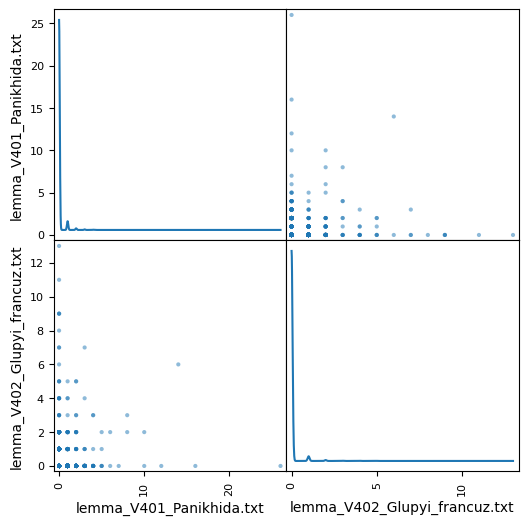

In [11]:
#матрица рассеяния для двух произведений
two_texts = dataset[['lemma_V401_Panikhida.txt', 'lemma_V402_Glupyi_francuz.txt']]
scatter_matrix(two_texts, figsize=(6, 6), diagonal='kde')
plt.show()

In [ ]:
# Scatterplot Matrix (TF-IDF)
#очень долго загружается
scatter_matrix(dataset_tfidf, figsize=(30,30))
plt.show()

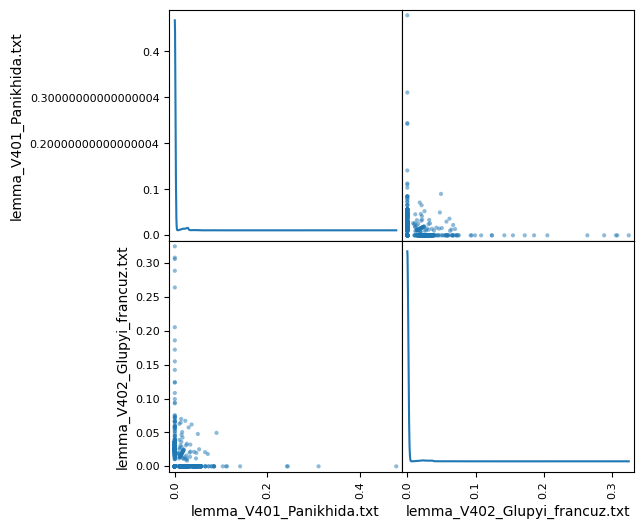

In [12]:
two_texts = dataset_tfidf[['lemma_V401_Panikhida.txt', 'lemma_V402_Glupyi_francuz.txt']]
scatter_matrix(two_texts, figsize=(6, 6), diagonal='kde')
plt.show()

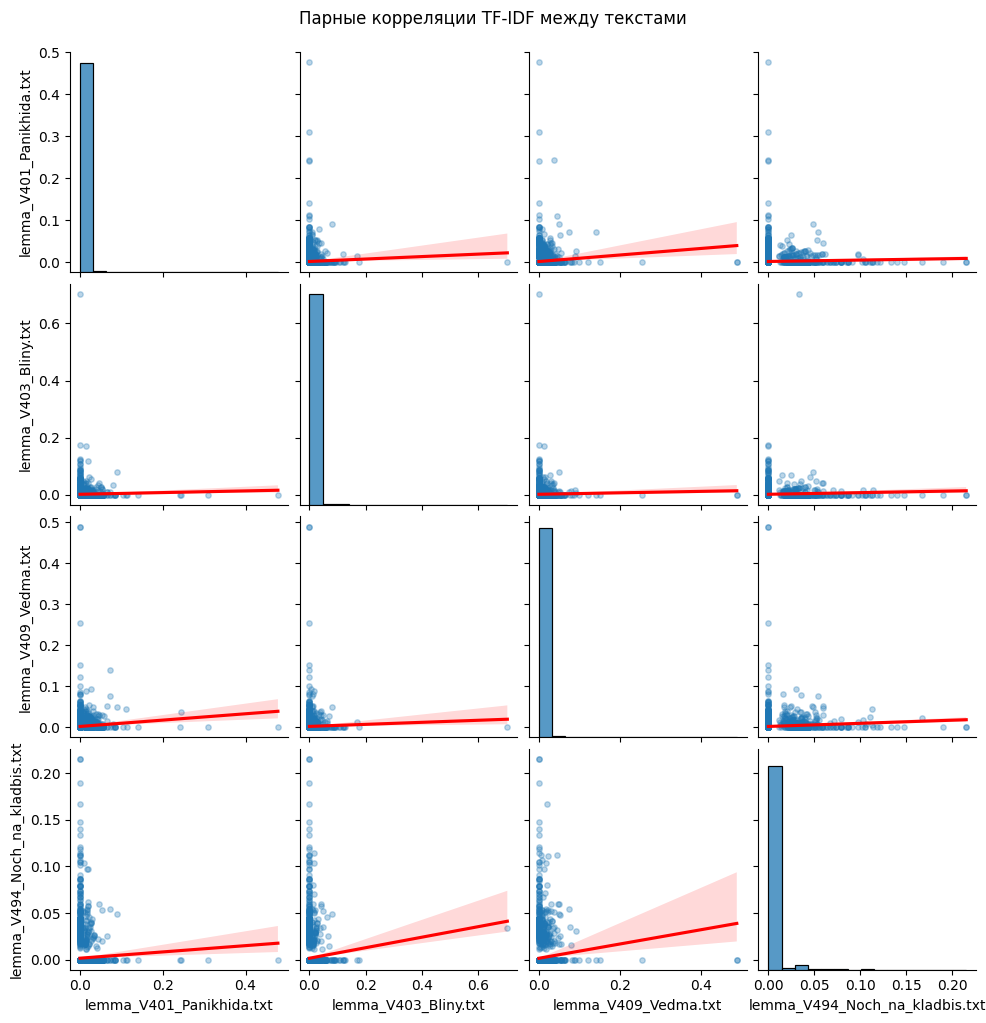

In [ ]:
# Scatterplot Plot (CV) Диаграмма рассеяния TF-IDF
selected_texts = ['lemma_V401_Panikhida.txt',
                 'lemma_V403_Bliny.txt',
                 'lemma_V409_Vedma.txt',
                 'lemma_V494_Noch_na_kladbis.txt']
import seaborn as sns
import matplotlib.pyplot as plt

# Создаем подвыборку данных
sample_data = dataset_tfidf[selected_texts]

# Парные scatter plots с регрессией
sns.pairplot(sample_data,
             kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15},
                      'line_kws': {'color': 'red'}})
plt.suptitle('Парные корреляции TF-IDF между текстами', y=1.02)
plt.show()

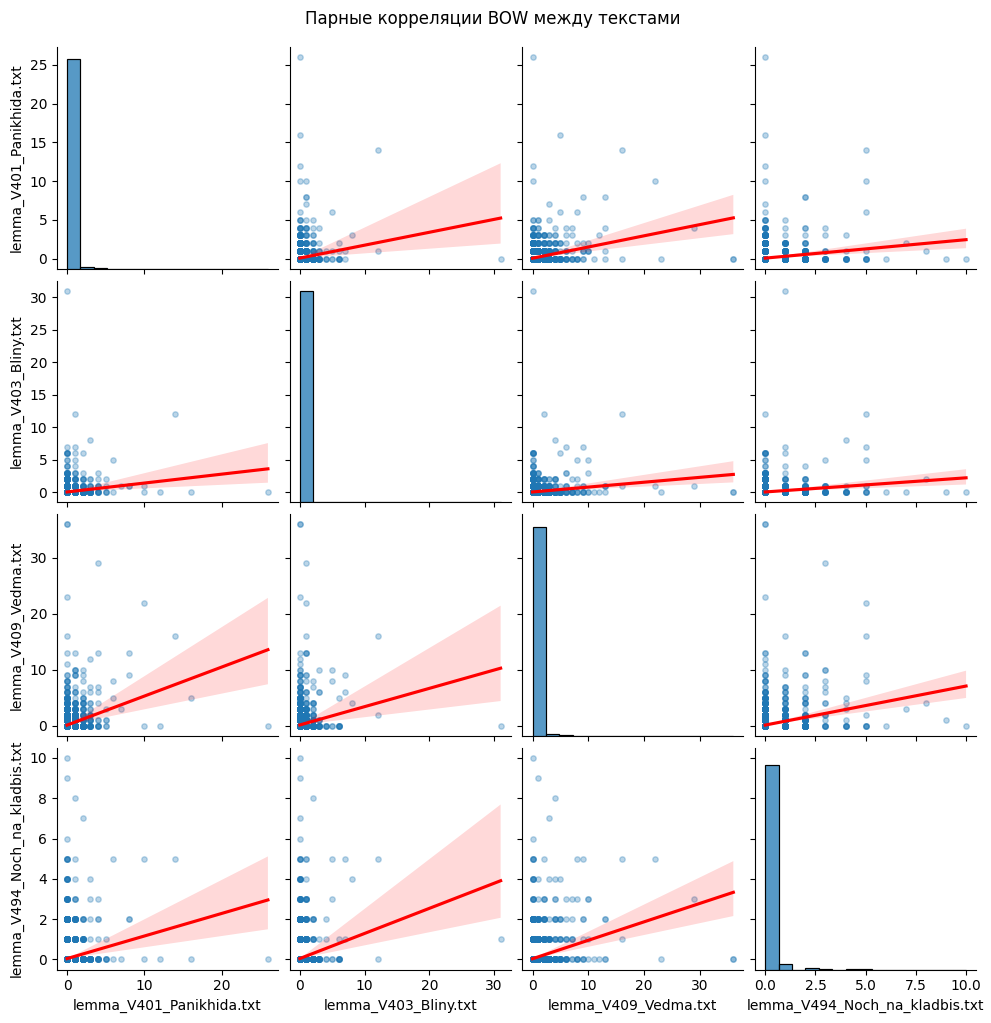

In [ ]:
# Scatterplot Plot (CV) Диаграмма рассеяния BOW
selected_texts = ['lemma_V401_Panikhida.txt',
                 'lemma_V403_Bliny.txt',
                 'lemma_V409_Vedma.txt',
                 'lemma_V494_Noch_na_kladbis.txt']

import seaborn as sns
import matplotlib.pyplot as plt

# Создаем подвыборку данных
sampledata = dataset[selected_texts]

# Парные scatter plots с регрессией
sns.pairplot(sampledata,
             kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15},
                      'line_kws': {'color': 'red'}})
plt.suptitle('Парные корреляции BOW между текстами', y=1.02)
plt.show()

In [8]:
file_namef = 'chekhov_tfidf_uni_transposed.csv'
dataset_tfidf = pd.read_csv(os.path.join(folder, file_namef))
dataset_tfidf.loc[dataset_tfidf['lemma_V407_Rybe_delo_(Gust.txt'].idxmax(), 'term']

'щука'

In [ ]:
file_name = 'chekhov_bow_uni_transposed.csv'
dataset = pd.read_csv(os.path.join(folder, file_name))
dataset.loc[dataset['lemma_V403_Bliny.txt'].idxmax(), 'Unnamed: 0']   # самое частое слово в тексте (выброс?)

'блин'